# Quantum Fourier Transform

For an $n$-qubit state $|x\rangle$, the Quantum Fourier Transform implements a basis change from the standard computational basis to the Fourier basis, where each basis state is a uniform superposition of position states with different phase rotation frequencies. For $N=2^n$, the QFT thus performs $|x\rangle\to\frac{1}{\sqrt{N}}\sum_{y=0}^{N-1}e^{2\pi i x\cdot y/N}|y\rangle$.

The inverse QFT performs the inverse transformation, $|x\rangle\to\frac{1}{\sqrt{N}}\sum_{y=0}^{N-1}e^{-2\pi i x\cdot y/N}|y\rangle$. Given a state in its Fourier basis, the inverse QFT retrieves the state's computational basis representation, thus determining the definite positional value corresponding to some phase pattern.

Both the QFT and inverse QFT play essential roles in period-finding algorithms such as quantum phase estimation and Shor's algorithm, where transforming a state with the QFT allows for taking advantage of phase patterns inherent in periodic functions while the inverse QFT is essential to return to a meaningfully measurable basis.

In [48]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import UnitaryGate
from IPython.display import display
from qiskit.quantum_info import Operator
import numpy as np

## QFT

The QFT is implemented by creating an $n$-qubit superposition through Hadamard gates. Subsequently, the phase rotations defined by $U_k = \text{diag}(1, e^{2\pi i / 2^k})$ apply increasingly precise phase corrections between the qubits, with the phase corrections implemented as controlled gates from qubit $j$ to qubit $i$, resulting in each output basis state having its distinct relative phase.

In this notebook I focused on implementing the QFT such that the circuit diagram would be visually clear. As such I omitted the final swap gates in standard implementations such as Qiskit's built-in QFT, resulting in a reversed output qubit order. To avoid confusion downstream notebooks using QFT or inverse QFT use Qiskit's built-in version rather than this one.

In [49]:
def make_unitaries(k):
    unitaries = []
    for i in range(2, k+1):
        unitary = np.diag([1, np.exp(2 * np.pi * 1j * 2**(-i))])
        unitary_gate = UnitaryGate(unitary, 'U')
        c_unitary = unitary_gate.control(1)
        unitaries.append(c_unitary)
    return unitaries

In [50]:
def make_qft_circuit(n):
    unitaries = make_unitaries(n)
    qc = QuantumCircuit(n)
    for i in range(n):
        qc.h(i)
        for j in range(i+1, n):
            qc.append(unitaries[j-i-1], [j, i])
    return qc

## Inverse QFT

Since the QFT is a unitary matrix, the inverse QFT is its conjugate transpose, which is the QFT circuit reversed with each gate conjugated. Thus it applies the controlled phase rotation unitaries before the Hadamard gates, and the controlled phase rotations apply negative phases, $U^\dagger_k = \text{diag}(1, e^{-2\pi i / 2^k})$.

In [51]:
def make_inverse_unitaries(k):
    unitaries = []
    for i in range(2, k+1):
        unitary = np.diag([1, np.exp(-2 * np.pi * 1j * 2**(-i))])
        unitary_gate = UnitaryGate(unitary, 'U')
        c_unitary = unitary_gate.control(1)
        unitaries.append(c_unitary)
    return unitaries

In [52]:
def make_inverse_qft_circuit(n):
    unitaries = make_inverse_unitaries(n)
    qc = QuantumCircuit(n)
    for i in range(n-1, -1, -1):
        for j in range(n-1, i, -1):
            qc.append(unitaries[j-i-1], [j, i])
        qc.h(i)
    return qc

## Testing

On input state $|0000\rangle$, $e^{2\pi i 0\cdot y/N} = 1$ for all $y$, so we expect a uniform superposition with equal phases. By contrast on $|1000\rangle$, which corresponds to the $x=1$ state in my reversed convention, we should still see equal magnitudes across all basis states, but with $e^{2\pi i y/16}$ on each $|y\rangle$ meaning each basis accumulates an additional relative phase of $\pi/8$ going around through all 16 states.

Input |0000⟩:


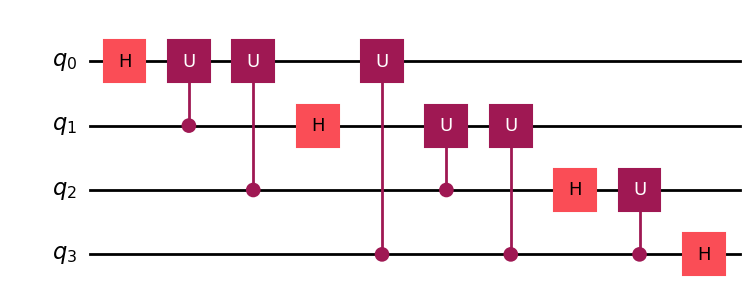

<IPython.core.display.Latex object>

Input |1000⟩:


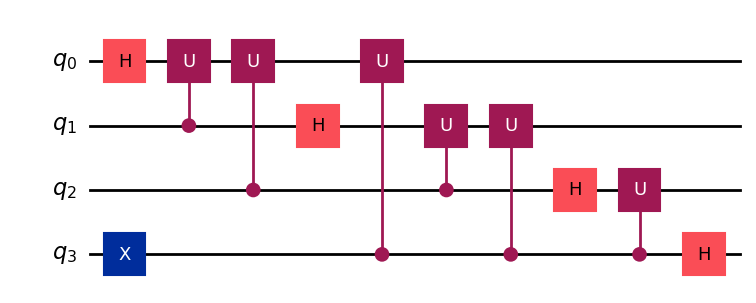

<IPython.core.display.Latex object>

In [53]:
# Test 1: |0000⟩ input
qc1 = QuantumCircuit(4)
qc1.compose(make_qft_circuit(4), inplace=True)
state1 = Statevector(qc1)
print('Input |0000⟩:')
display(qc1.draw('mpl'))
display(state1.draw('latex'))

# Test 2: |1000⟩ input (X on qubit 3)
qc2 = QuantumCircuit(4)
qc2.x(3)
qc2.compose(make_qft_circuit(4), inplace=True)
state2 = Statevector(qc2)
print('Input |1000⟩:')
display(qc2.draw('mpl'))
display(state2.draw('latex'))

Verifying QFT implementation against mathematical definition by checking against matrix construction. Again, due to omission of swap gates in my implementation, standard QFT matrix should match my implementation after bit-reversing input. This confirms that my implementation accurately performs the QFT. 

In [54]:
def qft_matrix(n):
    N = 2**n
    M = np.zeros((N, N), dtype=complex)
    for x in range(N):
        for y in range(N):
            M[y, x] = np.exp(2j * np.pi * x * y / N) / np.sqrt(N)
    return M
def bit_reverse(i, n):
    return int(format(i, f'0{n}b')[::-1], 2)
n = 4
expected = qft_matrix(n)
your_matrix = Operator(make_qft_circuit(n)).data
perm = [bit_reverse(i, n) for i in range(2**n)] #permute input columns for bit-reversed
bit_reversed_input = expected[:, perm]
print("Matches standard QFT with bit-reversed input:", np.allclose(your_matrix, bit_reversed_input))

Matches standard QFT with bit-reversed input: True


Since the QFT and inverse QFT are inverses, performing both unitaries should be equivalent to the identity matrix. I can verify this easily by creating some arbitrary state, copying it, performing the QFT and its inverse, and seeing if both states are identical. With previous test confirming QFT is mathematically accurate, this confirms the same for inverse QFT as well.

In [55]:
n = 4
qc = QuantumCircuit(n)
qc.h(0)
qc.x(1)
qc.h(2) #arbitrary nontrivial state
initial = Statevector(qc).data.copy()
qc.compose(make_qft_circuit(n), inplace=True)
qc.compose(make_inverse_qft_circuit(n), inplace=True)
final = Statevector(qc).data
print(f'QFT followed by inverse returns original state: {np.allclose(initial, final)}')

QFT followed by inverse returns original state: True
